## Step 1: Import Libraries and Load Dataset

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler



df = pd.read_csv('../Data/cardekho_dataset.csv')
print("Shape:", df.shape)


Shape: (15411, 14)


## Step 2: First look at the data

In [67]:
print("Shape:", df.shape)

Shape: (15411, 14)


In [68]:
df.dtypes

Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

In [69]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [70]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [71]:
df.nunique()

Unnamed: 0           15411
car_name               121
brand                   32
model                  120
vehicle_age             24
km_driven             3688
seller_type              3
fuel_type                5
transmission_type        2
mileage                411
engine                 110
max_power              342
seats                    8
selling_price         1086
dtype: int64

## Step 3: Detect Issues

In [72]:
print(df["seats"].value_counts())

seats
5    12910
7     1922
8      311
6      127
4       77
9       55
2        7
0        2
Name: count, dtype: int64


In [73]:
print(df["km_driven"].describe())
print()
# Show rows where km_driven seems unrealistic
print(df[df["km_driven"] > 500000][["car_name", "vehicle_age", "km_driven", "selling_price"]])

count    1.541100e+04
mean     5.561648e+04
std      5.161855e+04
min      1.000000e+02
25%      3.000000e+04
50%      5.000000e+04
75%      7.000000e+04
max      3.800000e+06
Name: km_driven, dtype: float64

                    car_name  vehicle_age  km_driven  selling_price
2731               Ford Figo           10     570000         200000
4532          Renault Duster            4     850000         850000
6712        Volkswagen Vento            9     830000         380000
7323           Ford Ecosport            6     720000         675000
7534         Toyota Fortuner            2     590000        2850000
8772           Toyota Innova            6     950000         950000
9170             Skoda Rapid            5     675000         675000
10384             Honda Jazz            4     525000         525000
10838          Hyundai Creta            6     825000         825000
11615        Volkswagen Polo            5     820000         695000
11903  Mercedes-Benz E-Class            9  

In [74]:
print(df["selling_price"].describe())
print()
# Cars priced above 5 crore (50,000,000) — likely data errors
print(df[df["selling_price"] > 5000000][["car_name", "vehicle_age", "km_driven", "selling_price"]])

count    1.541100e+04
mean     7.749711e+05
std      8.941284e+05
min      4.000000e+04
25%      3.850000e+05
50%      5.560000e+05
75%      8.250000e+05
max      3.950000e+07
Name: selling_price, dtype: float64

                car_name  vehicle_age  km_driven  selling_price
285     Land Rover Rover            3      13000        7000000
311               BMW Z4            1       2000        8250000
318     Land Rover Rover            3      25000        6200000
323                BMW 6            3      30000        5500000
351               BMW X5            2      19000        7900000
...                  ...          ...        ...            ...
14701   Land Rover Rover            7      61000        5700000
14707              BMW 5            1      15000        5400000
15129      Jeep Wrangler            2      32000        5600000
15251  Mercedes-Benz GLS            3      15000        8000000
15287              BMW 5            2       4000        5295000

[116 rows x 4 colu

In [75]:
print(df[["car_name", "brand", "model"]].head(15))

          car_name    brand     model
0      Maruti Alto   Maruti      Alto
1    Hyundai Grand  Hyundai     Grand
2      Hyundai i20  Hyundai       i20
3      Maruti Alto   Maruti      Alto
4    Ford Ecosport     Ford  Ecosport
5   Maruti Wagon R   Maruti   Wagon R
6      Hyundai i10  Hyundai       i10
7   Maruti Wagon R   Maruti   Wagon R
8    Hyundai Venue  Hyundai     Venue
9     Maruti Swift   Maruti     Swift
10   Hyundai Verna  Hyundai     Verna
11  Renault Duster  Renault    Duster
12     Mini Cooper     Mini    Cooper
13     Maruti Ciaz   Maruti      Ciaz
14    Maruti Swift   Maruti     Swift


In [76]:
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})
missing_info

,Missing Count,Missing %
Unnamed: 0,0,0.0
car_name,0,0.0
brand,0,0.0
model,0,0.0
vehicle_age,0,0.0
km_driven,0,0.0
seller_type,0,0.0
fuel_type,0,0.0
transmission_type,0,0.0
mileage,0,0.0


## Step 4: Cleaning the Data

In [77]:
#Drop Unnamed:0 and car_name (redundant columns)
df.drop(columns=["Unnamed: 0", "car_name"], inplace=True)
print("Columns after:", df.columns.tolist())

Columns after: ['brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


In [78]:
#Drop rows where car seats = 0
print("Rows with seats = 0:")
print(df[df["seats"] == 0])

Rows with seats = 0:
        brand  model  vehicle_age  km_driven seller_type fuel_type  \
3217    Honda   City           18      40000  Individual    Petrol   
12619  Nissan  Kicks            2      10000  Individual    Diesel   

      transmission_type  mileage  engine  max_power  seats  selling_price  
3217             Manual    13.00    1493     100.00      0         115000  
12619            Manual    19.39    1461     108.49      0        1154000  


In [79]:
df = df[df["seats"] != 0]
print("Shape after removing seats=0:", df.shape)

Shape after removing seats=0: (15409, 12)


In [80]:
# Drop km_driven outliers
# Anything above 1,000,000 km is unrealistic
print("Rows with km_driven above 1,000,000:")
print(df[df["km_driven"] > 1000000][["brand", "model", "vehicle_age", "km_driven", "selling_price"]])

Rows with km_driven above 1,000,000:
               brand    model  vehicle_age  km_driven  selling_price
11903  Mercedes-Benz  E-Class            9    1325000        1350000
15409       Mahindra   XUV500            5    3800000        1225000


In [81]:
df = df[df["km_driven"] <= 1000000]
print("Shape after removing km outliers:", df.shape)

Shape after removing km outliers: (15407, 12)


In [82]:
#check duplicates
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 167


In [83]:

df[df.duplicated(keep=False)]

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
25,Maruti,Swift Dzire,6,90000,Individual,Diesel,Manual,26.59,1248,74.00,5,600000
67,Honda,City,8,70000,Individual,Petrol,Manual,16.80,1497,116.30,5,545000
159,Maruti,Alto,2,25000,Individual,Petrol,Manual,24.70,796,47.30,5,310000
197,Honda,City,8,70000,Individual,Petrol,Manual,16.80,1497,116.30,5,545000
214,Renault,KWID,4,35000,Individual,Petrol,Automatic,24.04,999,67.00,5,350000
...,...,...,...,...,...,...,...,...,...,...,...,...
15229,Maruti,Swift,8,80000,Individual,Diesel,Manual,22.90,1248,74.00,5,350000
15324,Maruti,Wagon R,6,50000,Individual,CNG,Manual,26.60,998,58.16,5,450000
15367,Tata,Tiago,4,30000,Individual,Petrol,Manual,23.84,1199,84.00,5,350000
15378,Hyundai,Grand,6,30000,Individual,Petrol,Manual,18.90,1197,82.00,5,450000


In [84]:

df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (15240, 12)


In [85]:
print("Final shape:", df.shape)
print("\nNull values:\n", df.isnull().sum())
print("\nDtypes:\n", df.dtypes)
df.head()

Final shape: (15240, 12)

Null values:
 brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Dtypes:
 brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object


,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [86]:
## Droping original selling_price keeping the log version
if "selling_price" in df.columns:
    df["selling_price_log"] = np.log(df["selling_price"])

df.drop(columns=["selling_price"], inplace=True, errors="ignore")

print("Columns now:", df.columns.tolist())

Columns now: ['brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price_log']


## Step 5: EDA (Exploratory Data Analysis)


###  Selling price distribution

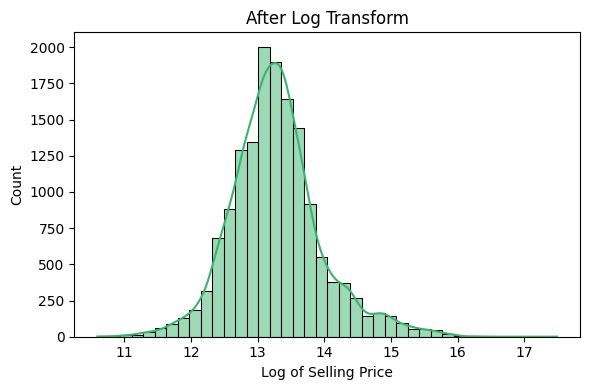

In [87]:
plt.figure(figsize=(6,4))

sns.histplot(df["selling_price_log"], bins=40, kde=True, color="mediumseagreen")

plt.title("After Log Transform")
plt.xlabel("Log of Selling Price")

plt.tight_layout()
plt.show()

### Price by Brand

C:\Users\Hamza\AppData\Local\Temp\ipykernel_26060\4196387.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="brand", y="selling_price_log", palette="Set2")


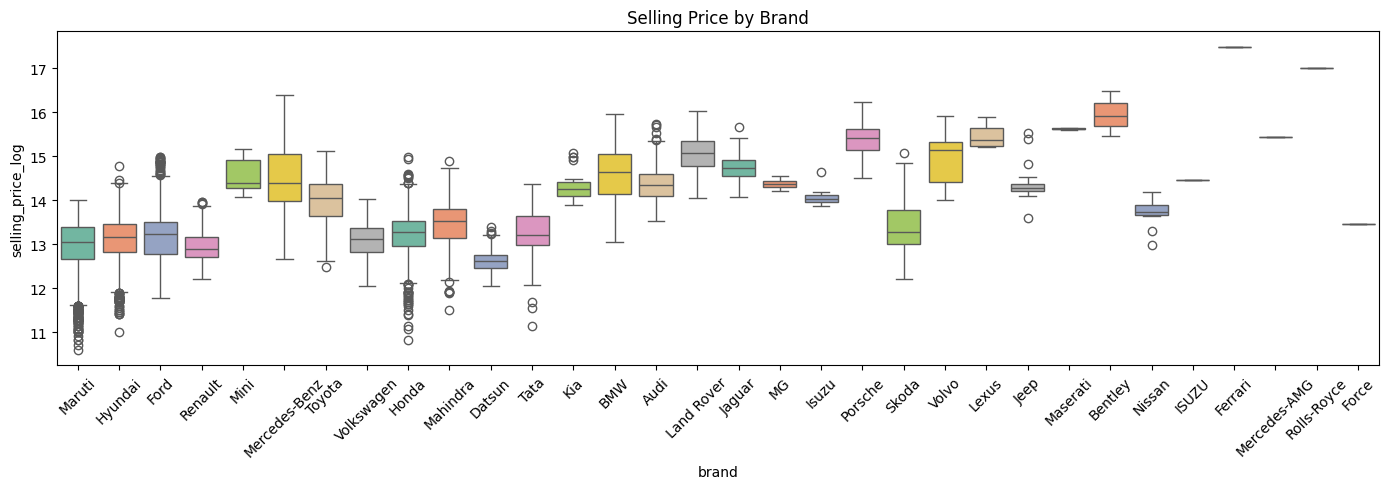

In [88]:
plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x="brand", y="selling_price_log", palette="Set2")
plt.xticks(rotation=45)
plt.title("Selling Price by Brand")
plt.tight_layout()
plt.show()

### Price by Fuel Type

C:\Users\Hamza\AppData\Local\Temp\ipykernel_26060\1298403191.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="fuel_type", y="selling_price_log", palette="Set3")


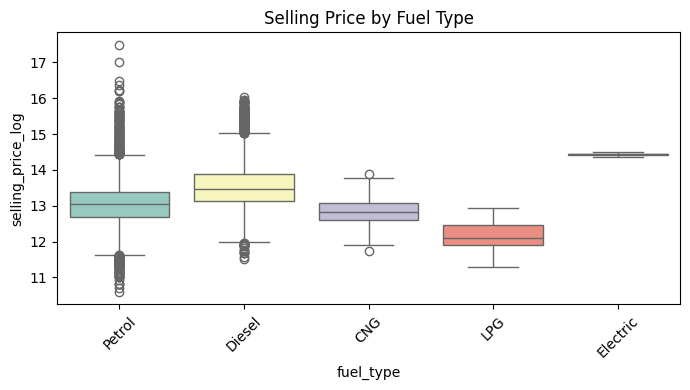

In [89]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="fuel_type", y="selling_price_log", palette="Set3")
plt.xticks(rotation=45)
plt.title("Selling Price by Fuel Type")
plt.tight_layout()
plt.show()

C:\Users\Hamza\AppData\Local\Temp\ipykernel_26060\3902662629.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="transmission_type", y="selling_price_log", palette="pastel")


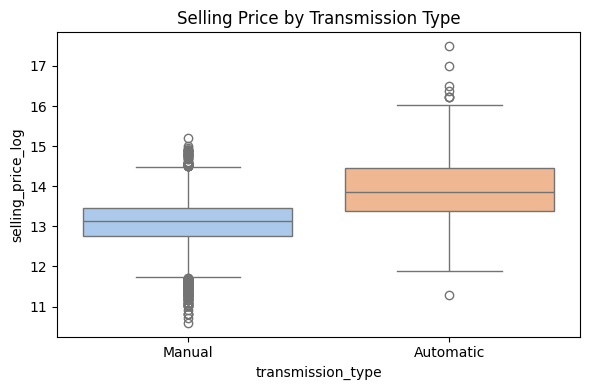

In [90]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="transmission_type", y="selling_price_log", palette="pastel")
plt.title("Selling Price by Transmission Type")
plt.tight_layout()
plt.show()

C:\Users\Hamza\AppData\Local\Temp\ipykernel_26060\244353053.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="seller_type", y="selling_price_log", palette="muted")


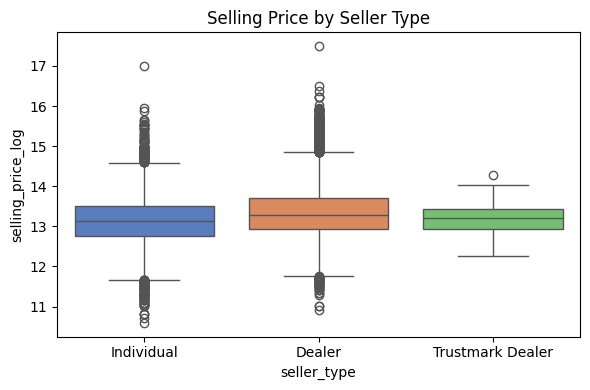

In [91]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="seller_type", y="selling_price_log", palette="muted")
plt.title("Selling Price by Seller Type")
plt.tight_layout()
plt.show()

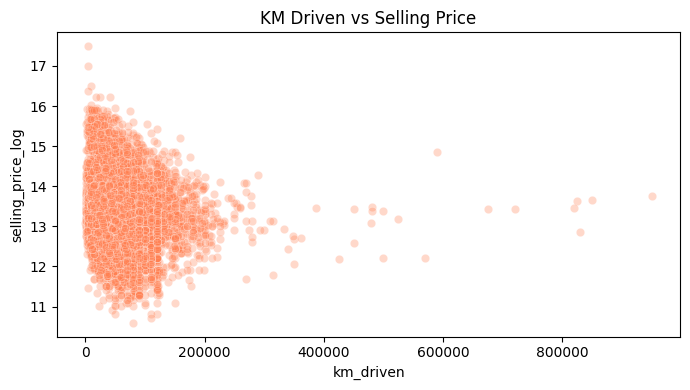

In [92]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x="km_driven", y="selling_price_log", alpha=0.3, color="coral")
plt.title("KM Driven vs Selling Price")
plt.tight_layout()
plt.show()

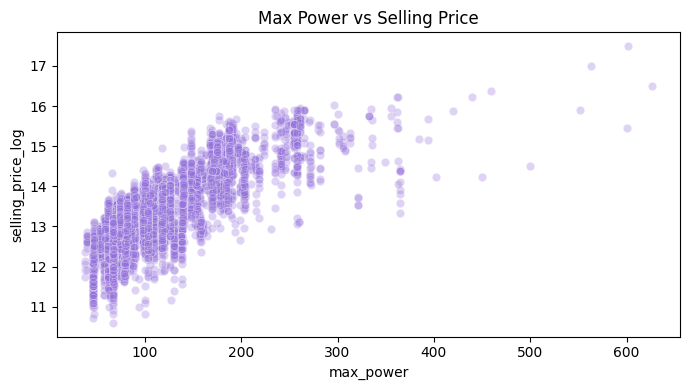

In [93]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x="max_power", y="selling_price_log", alpha=0.3, color="mediumpurple")
plt.title("Max Power vs Selling Price")
plt.tight_layout()
plt.show()

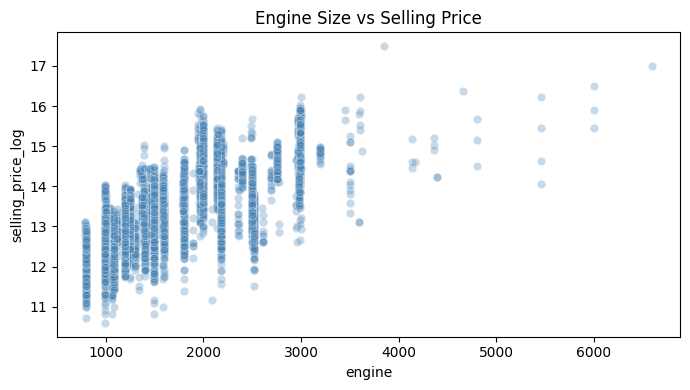

In [95]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x="engine", y="selling_price_log", alpha=0.3, color="steelblue")
plt.title("Engine Size vs Selling Price")
plt.tight_layout()
plt.show()

C:\Users\Hamza\AppData\Local\Temp\ipykernel_14952\3193335782.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="seats", palette="muted")


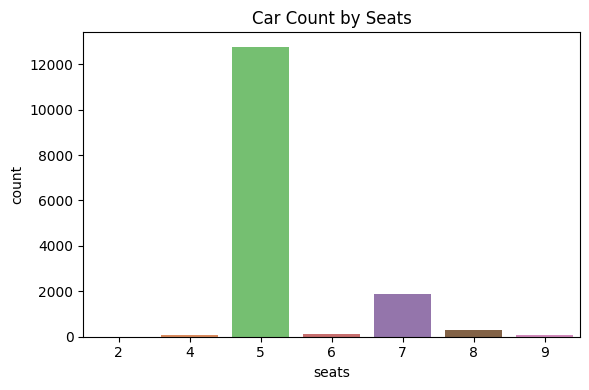

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="seats", palette="muted")
plt.title("Car Count by Seats")
plt.tight_layout()
plt.show()

## Step 6: Encode Categorical Features

In [96]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", categorical_cols)
print()
for col in categorical_cols:
    print(f"{col} — {df[col].nunique()} unique values")
    print(df[col].unique())
    print()

Categorical columns: ['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

brand — 32 unique values
['Maruti' 'Hyundai' 'Ford' 'Renault' 'Mini' 'Mercedes-Benz' 'Toyota'
 'Volkswagen' 'Honda' 'Mahindra' 'Datsun' 'Tata' 'Kia' 'BMW' 'Audi'
 'Land Rover' 'Jaguar' 'MG' 'Isuzu' 'Porsche' 'Skoda' 'Volvo' 'Lexus'
 'Jeep' 'Maserati' 'Bentley' 'Nissan' 'ISUZU' 'Ferrari' 'Mercedes-AMG'
 'Rolls-Royce' 'Force']

model — 120 unique values
['Alto' 'Grand' 'i20' 'Ecosport' 'Wagon R' 'i10' 'Venue' 'Swift' 'Verna'
 'Duster' 'Cooper' 'Ciaz' 'C-Class' 'Innova' 'Baleno' 'Swift Dzire'
 'Vento' 'Creta' 'City' 'Bolero' 'Fortuner' 'KWID' 'Amaze' 'Santro'
 'XUV500' 'KUV100' 'Ignis' 'RediGO' 'Scorpio' 'Marazzo' 'Aspire' 'Figo'
 'Vitara' 'Tiago' 'Polo' 'Seltos' 'Celerio' 'GO' '5' 'CR-V' 'Endeavour'
 'KUV' 'Jazz' '3' 'A4' 'Tigor' 'Ertiga' 'Safari' 'Thar' 'Hexa' 'Rover'
 'Eeco' 'A6' 'E-Class' 'Q7' 'Z4' '6' 'XF' 'X5' 'Hector' 'Civic' 'D-Max'
 'Cayenne' 'X1' 'Rapid' 'Freestyle' 'Superb' 'Nexon' 'XUV300

In [97]:
#drop model column since it has too many unique values and is not useful for prediction
df.drop(columns=["model"], inplace=True)

In [98]:

print("Columns now:", df.columns.tolist())

Columns now: ['brand', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price_log']


### Apply One hot Encoding

In [99]:
categorical_cols = ["brand", "seller_type", "fuel_type", "transmission_type"]

df = pd.get_dummies(df, columns=categorical_cols)

print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (15240, 49)


,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price_log,brand_Audi,brand_BMW,brand_Bentley,...,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,11.695247,False,False,False,...,False,True,False,False,False,False,False,True,False,True
1,5,20000,18.90,1197,82.00,5,13.217674,False,False,False,...,False,True,False,False,False,False,False,True,False,True
2,11,60000,17.00,1197,80.00,5,12.278393,False,False,False,...,False,True,False,False,False,False,False,True,False,True
3,9,37000,20.92,998,67.10,5,12.328290,False,False,False,...,False,True,False,False,False,False,False,True,False,True
4,6,30000,22.77,1498,98.59,5,13.253392,False,False,False,...,True,False,False,False,True,False,False,False,False,True


In [100]:
df.dtypes

vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
selling_price_log               float64
brand_Audi                         bool
brand_BMW                          bool
brand_Bentley                      bool
brand_Datsun                       bool
brand_Ferrari                      bool
brand_Force                        bool
brand_Ford                         bool
brand_Honda                        bool
brand_Hyundai                      bool
brand_ISUZU                        bool
brand_Isuzu                        bool
brand_Jaguar                       bool
brand_Jeep                         bool
brand_Kia                          bool
brand_Land Rover                   bool
brand_Lexus                        bool
brand_MG                           bool
brand_Mahindra                     bool


In [101]:
#  Convert bool columns to int
df = df.astype({col: int for col in df.select_dtypes(include="bool").columns})
print("Done")
df.dtypes

Done


vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
selling_price_log               float64
brand_Audi                        int64
brand_BMW                         int64
brand_Bentley                     int64
brand_Datsun                      int64
brand_Ferrari                     int64
brand_Force                       int64
brand_Ford                        int64
brand_Honda                       int64
brand_Hyundai                     int64
brand_ISUZU                       int64
brand_Isuzu                       int64
brand_Jaguar                      int64
brand_Jeep                        int64
brand_Kia                         int64
brand_Land Rover                  int64
brand_Lexus                       int64
brand_MG                          int64
brand_Mahindra                    int64


In [102]:
print("Shape:", df.shape)
print("Any nulls:", df.isnull().sum().sum())
df.head()

Shape: (15240, 49)
Any nulls: 0


,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price_log,brand_Audi,brand_BMW,brand_Bentley,...,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,11.695247,0,0,0,...,0,1,0,0,0,0,0,1,0,1
1,5,20000,18.90,1197,82.00,5,13.217674,0,0,0,...,0,1,0,0,0,0,0,1,0,1
2,11,60000,17.00,1197,80.00,5,12.278393,0,0,0,...,0,1,0,0,0,0,0,1,0,1
3,9,37000,20.92,998,67.10,5,12.328290,0,0,0,...,0,1,0,0,0,0,0,1,0,1
4,6,30000,22.77,1498,98.59,5,13.253392,0,0,0,...,1,0,0,0,1,0,0,0,0,1


## Step 7: Split the Data

#### Define features and target

In [107]:
X = df.drop(columns=["selling_price_log"])
y = df["selling_price_log"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15240, 48)
y shape: (15240,)


#### Train/test split

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")

Training set: (12192, 48)
Testing set:  (3048, 48)


## Step 8: Feature scaling

In [109]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done")

Scaling done


## Step 9: Train the Model

In [110]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model trained successfully")

Model trained successfully


## Step 10: Evaluate the Model

In [111]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

print("Intercept:", model.intercept_)
print()
coefficients

Intercept: 13.28067303729629



,Feature,Coefficient
4,max_power,2.835966e-01
42,fuel_type_Diesel,7.095680e-02
3,engine,6.202277e-02
7,brand_BMW,6.187720e-02
6,brand_Audi,4.208314e-02
27,brand_Mercedes-Benz,4.161714e-02
20,brand_Land Rover,3.662695e-02
5,seats,3.399607e-02
28,brand_Mini,2.868338e-02
35,brand_Toyota,2.849306e-02


In [112]:
y_pred = model.predict(X_test_scaled)

In [113]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.1724
RMSE : 0.2235
R²   : 0.8931


In [114]:
# Since we trained on log prices we need to reverse the log to see real rupee values
y_test_actual = np.exp(y_test)
y_pred_actual = np.exp(y_pred)

mae_actual  = mean_absolute_error(y_test_actual, y_pred_actual)
rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print(f"MAE  in actual price : ₹{mae_actual:,.0f}")
print(f"RMSE in actual price : ₹{rmse_actual:,.0f}")

MAE  in actual price : ₹136,469
RMSE in actual price : ₹299,486


In [115]:
comparison = pd.DataFrame({
    "Actual Price":    y_test_actual.values[:10].round(0),
    "Predicted Price": y_pred_actual[:10].round(0)
})
print(comparison)

   Actual Price  Predicted Price
0      650000.0         513513.0
1      165000.0         182397.0
2      250000.0         417746.0
3     1200000.0        1108081.0
4      745000.0         947434.0
5      395000.0         534722.0
6      610000.0         487476.0
7      480000.0         521089.0
8      789000.0         554118.0
9      200000.0         224187.0


In [116]:
train_score = r2_score(y_train, model.predict(X_train_scaled))
test_score  = r2_score(y_test, y_pred)

print(f"Training R²  : {train_score:.4f}")
print(f"Testing R²   : {test_score:.4f}")
print(f"Difference   : {abs(train_score - test_score):.4f}")

Training R²  : 0.8955
Testing R²   : 0.8931
Difference   : 0.0024


## Manually predicting a single example

In [117]:
print(X.columns.tolist())

['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'brand_Audi', 'brand_BMW', 'brand_Bentley', 'brand_Datsun', 'brand_Ferrari', 'brand_Force', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_ISUZU', 'brand_Isuzu', 'brand_Jaguar', 'brand_Jeep', 'brand_Kia', 'brand_Land Rover', 'brand_Lexus', 'brand_MG', 'brand_Mahindra', 'brand_Maruti', 'brand_Maserati', 'brand_Mercedes-AMG', 'brand_Mercedes-Benz', 'brand_Mini', 'brand_Nissan', 'brand_Porsche', 'brand_Renault', 'brand_Rolls-Royce', 'brand_Skoda', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen', 'brand_Volvo', 'seller_type_Dealer', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'fuel_type_CNG', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'transmission_type_Automatic', 'transmission_type_Manual']


In [118]:
# We are predicting price for:
# Maruti, 5 years old, 45000 km, Petrol, Manual, Individual seller
sample_car = pd.DataFrame(columns=X.columns)
sample_car.loc[0] = 0  # fill everything with 0 first

# Numeric values
sample_car["vehicle_age"] = 5
sample_car["km_driven"]   = 45000
sample_car["mileage"]     = 21.0
sample_car["engine"]      = 1197
sample_car["max_power"]   = 82.0
sample_car["seats"]       = 5

# Brand — set only the one that applies to 1
sample_car["brand_Maruti"] = 1

# Fuel type
sample_car["fuel_type_Petrol"] = 1

# Transmission
sample_car["transmission_type_Manual"] = 1

# Seller type
sample_car["seller_type_Individual"] = 1

print("Sample car:")
print(f"  Vehicle age : {sample_car['vehicle_age'].values[0]} years")
print(f"  KM driven   : {sample_car['km_driven'].values[0]:,}")
print(f"  Mileage     : {sample_car['mileage'].values[0]} kmpl")
print(f"  Engine      : {sample_car['engine'].values[0]} cc")
print(f"  Max power   : {sample_car['max_power'].values[0]} bhp")
print(f"  Seats       : {sample_car['seats'].values[0]}")
print(f"  Brand       : Maruti")
print(f"  Fuel        : Petrol")
print(f"  Transmission: Manual")
print(f"  Seller type : Individual")

Sample car:
  Vehicle age : 5 years
  KM driven   : 45,000
  Mileage     : 21.0 kmpl
  Engine      : 1197 cc
  Max power   : 82.0 bhp
  Seats       : 5
  Brand       : Maruti
  Fuel        : Petrol
  Transmission: Manual
  Seller type : Individual


In [119]:
sample_car_scaled = scaler.transform(sample_car)
log_price         = model.predict(sample_car_scaled)
actual_price      = np.exp(log_price)

print(f"Predicted Price: ₹{actual_price[0]:,.0f}")

Predicted Price: ₹452,307


In [120]:
sample_car.loc[0] = 0

sample_car["vehicle_age"] = 5
sample_car["km_driven"]   = 45000
sample_car["mileage"]     = 12.0
sample_car["engine"]      = 2000
sample_car["max_power"]   = 190.0
sample_car["seats"]       = 5

sample_car["brand_BMW"]            = 1
sample_car["fuel_type_Petrol"]     = 1
sample_car["transmission_type_Automatic"] = 1
sample_car["seller_type_Dealer"]   = 1

log_price    = model.predict(scaler.transform(sample_car))
actual_price = np.exp(log_price)
print(f"BMW Predicted Price: ₹{actual_price[0]:,.0f}")

BMW Predicted Price: ₹2,021,779


In [121]:
sample_car.loc[0] = 0

sample_car["vehicle_age"] = 1      # brand new
sample_car["km_driven"]   = 5000   # barely driven
sample_car["mileage"]     = 21.0
sample_car["engine"]      = 1197
sample_car["max_power"]   = 82.0
sample_car["seats"]       = 5

sample_car["brand_Maruti"]              = 1
sample_car["fuel_type_Petrol"]          = 1
sample_car["transmission_type_Manual"]  = 1
sample_car["seller_type_Individual"]    = 1

log_price    = model.predict(scaler.transform(sample_car))
actual_price = np.exp(log_price)
print(f"Brand New Maruti Predicted Price: ₹{actual_price[0]:,.0f}")

Brand New Maruti Predicted Price: ₹749,420


## Saving the model

In [122]:
import joblib

joblib.dump(model, "car_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved as car_price_model.pkl")
print("Scaler saved as scaler.pkl")

Model saved as car_price_model.pkl
Scaler saved as scaler.pkl


In [123]:
import json

columns = X.columns.tolist()

with open("model_columns.json", "w") as f:
    json.dump(columns, f)

print("Columns saved as model_columns.json")
print(f"Total columns saved: {len(columns)}")

Columns saved as model_columns.json
Total columns saved: 48


In [124]:
model_loaded   = joblib.load("car_price_model.pkl")
scaler_loaded  = joblib.load("scaler.pkl")

with open("model_columns.json", "r") as f:
    columns_loaded = json.load(f)

print("Model loaded successfully:", type(model_loaded))
print("Scaler loaded successfully:", type(scaler_loaded))
print("Columns loaded successfully:", len(columns_loaded), "columns")

Model loaded successfully: <class 'sklearn.linear_model._base.LinearRegression'>
Scaler loaded successfully: <class 'sklearn.preprocessing._data.StandardScaler'>
Columns loaded successfully: 48 columns
